In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/utkface-new/UTKFace/26_0_2_20170104023102422.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/44_0_3_20170119201022260.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/35_0_2_20170116182734834.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/76_0_0_20170104213515132.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/36_1_0_20170116165722892.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/34_0_3_20170119200815948.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/18_1_0_20170104022856102.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/40_1_1_20170113011948248.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/45_0_0_20170117180013541.jpg.chip.jpg
/kaggle/input/utkface-new/UTKFace/26_1_1_20170117153641469.jpg.c

In [5]:
import os

print(os.listdir('/kaggle/input'))

['utkface-new']


In [7]:
import os
import glob

DATA_PATH = "/kaggle/input/utkface-new"

image_paths = glob.glob(DATA_PATH + "/**/*.jpg", recursive=True)

print("Total images:", len(image_paths))
print(image_paths[:5])

Total images: 66976
['/kaggle/input/utkface-new/UTKFace/26_0_2_20170104023102422.jpg.chip.jpg', '/kaggle/input/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg', '/kaggle/input/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg', '/kaggle/input/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg', '/kaggle/input/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg']


In [8]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 64
BATCH_SIZE = 64
MAX_IMAGES = 6000
NUM_CLASSES = 5

## cnn

In [9]:
paths = []
labels = []

for image_path in image_paths:

    filename = os.path.basename(image_path)
    parts = filename.split('_')

    if len(parts) >= 4:

        race = int(parts[2])

        if 0 <= race < 5:
            paths.append(image_path)
            labels.append(race)

paths = np.array(paths)
labels = np.array(labels)

print("Usable images:", len(paths))
print("Classes:", np.unique(labels))

Usable images: 66966
Classes: [0 1 2 3 4]


In [10]:
if len(paths) > MAX_IMAGES:

    indices = np.random.choice(
        len(paths),
        MAX_IMAGES,
        replace=False
    )

    paths = paths[indices]
    labels = labels[indices]

print("Images used:", len(paths))

Images used: 6000


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

print("Train:", len(X_train))
print("Test:", len(X_test))

Train: 4800
Test: 1200


In [12]:
def load_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [13]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

train_ds = (
    train_ds
    .shuffle(1000)
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Datasets ready!")

Datasets ready!


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

cnn_scratch = Sequential([

    Conv2D(16, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

cnn_scratch.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 62, 62, 16)        448       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 31, 31, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 29, 29, 32)        4640      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 12, 12, 64)        18496     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
flatten (Flatten)            (None, 2304)              0

In [15]:
cnn_scratch.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history_scratch = cnn_scratch.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
75/75 [==============================] - 20s 121ms/step - loss: 1.3899 - accuracy: 0.4748 - val_loss: 1.3059 - val_accuracy: 0.4975
Epoch 2/3
75/75 [==============================] - 2s 25ms/step - loss: 1.2450 - accuracy: 0.5202 - val_loss: 1.1768 - val_accuracy: 0.5392
Epoch 3/3
75/75 [==============================] - 2s 24ms/step - loss: 1.0794 - accuracy: 0.5954 - val_loss: 1.0497 - val_accuracy: 0.6042


In [52]:
loss_scratch, accuracy_scratch = cnn_scratch.evaluate(test_ds)

print("CNN Scratch Test Loss:", loss_scratch)
print("CNN Scratch Test Accuracy:", accuracy_scratch)

25/25 [==============================] - 0s 12ms/step - loss: 1.0356 - accuracy: 0.6100
CNN Scratch Test Loss: 1.035569667816162
CNN Scratch Test Accuracy: 0.6100000143051147


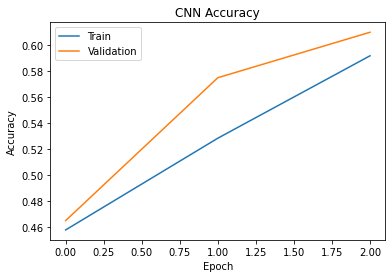

In [53]:
import matplotlib.pyplot as plt

plt.plot(history_scratch.history['accuracy'])
plt.plot(history_scratch.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.title("CNN Accuracy")

plt.show()

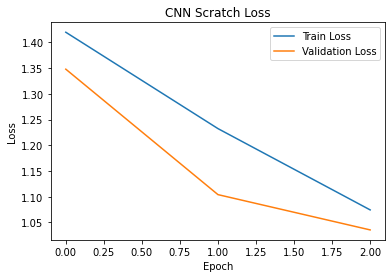

In [54]:
plt.figure(figsize=(6,4))

plt.plot(history_scratch.history['loss'], label='Train Loss')
plt.plot(history_scratch.history['val_loss'], label='Validation Loss')

plt.title('CNN Scratch Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Transfer learningg

In [55]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

In [56]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

print("Base model loaded")

Base model loaded


In [57]:
transfer_model = tf.keras.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

transfer_model.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenetv2_1.00_96 (Functio (None, 3, 3, 1280)        2257984   
_________________________________________________________________
global_average_pooling2d_2 ( (None, 1280)              0         
_________________________________________________________________
dense_8 (Dense)              (None, 64)                81984     
_________________________________________________________________
dropout_4 (Dropout)          (None, 64)                0         
_________________________________________________________________
dense_9 (Dense)              (None, 5)                 325       
Total params: 2,340,293
Trainable params: 82,309
Non-trainable params: 2,257,984
_________________________________________________________________


In [58]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=3
)

Epoch 1/3
100/100 [==============================] - 5s 25ms/step - loss: 1.3182 - accuracy: 0.4891 - val_loss: 1.1210 - val_accuracy: 0.5612
Epoch 2/3
100/100 [==============================] - 2s 17ms/step - loss: 1.1175 - accuracy: 0.5706 - val_loss: 1.0749 - val_accuracy: 0.5700
Epoch 3/3
100/100 [==============================] - 2s 18ms/step - loss: 1.0293 - accuracy: 0.6181 - val_loss: 1.0212 - val_accuracy: 0.6050


In [60]:
loss_transfer, accuracy_transfer = transfer_model.evaluate(test_ds)

print("Transfer Learning Test Loss:", loss_transfer)
print("Transfer Learning Test Accuracy:", accuracy_transfer)

25/25 [==============================] - 0s 13ms/step - loss: 1.0212 - accuracy: 0.6050
Transfer Learning Test Loss: 1.0212184190750122
Transfer Learning Test Accuracy: 0.6050000190734863


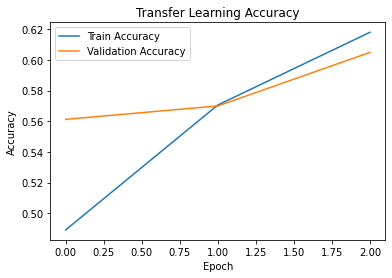

In [61]:
plt.figure(figsize=(6,4))

plt.plot(
    history_transfer.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_transfer.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

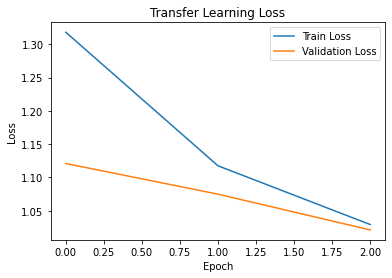

In [62]:
plt.figure(figsize=(6,4))

plt.plot(
    history_transfer.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_transfer.history['val_loss'],
    label='Validation Loss'
)

plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## fine tuning

In [63]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

print("Trainable layers:", sum(
    layer.trainable for layer in base_model.layers
))

Trainable layers: 10


In [64]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=2
)

Epoch 1/2
100/100 [==============================] - 5s 26ms/step - loss: 1.0976 - accuracy: 0.5928 - val_loss: 1.0454 - val_accuracy: 0.5913
Epoch 2/2
100/100 [==============================] - 2s 19ms/step - loss: 0.8494 - accuracy: 0.6891 - val_loss: 1.0248 - val_accuracy: 0.5975


In [66]:
loss_finetune, accuracy_finetune = transfer_model.evaluate(test_ds)

print("Fine-Tuning Test Loss:", loss_finetune)
print("Fine-Tuning Test Accuracy:", accuracy_finetune)

25/25 [==============================] - 0s 15ms/step - loss: 1.0248 - accuracy: 0.5975
Fine-Tuning Test Loss: 1.0248464345932007
Fine-Tuning Test Accuracy: 0.5975000262260437


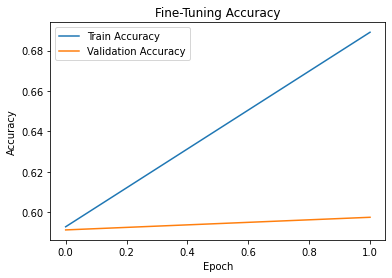

In [67]:
plt.figure(figsize=(6,4))

plt.plot(
    history_finetune.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_finetune.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [77]:

print("CNN Scratch Accuracy:", accuracy_scratch)
print("Transfer Learning Accuracy:", accuracy_transfer)
print("Fine-Tuning Accuracy:", accuracy_finetune)

CNN Scratch Accuracy: 0.6100000143051147
Transfer Learning Accuracy: 0.5975000262260437
Fine-Tuning Accuracy: 0.5975000262260437


In [69]:
results = {
    'Model': [
        'CNN Scratch',
        'Transfer Learning',
        'Fine-Tuning'
    ],
    
    'Test Accuracy': [
        accuracy_scratch,
        accuracy_transfer,
        accuracy_finetune
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Test Accuracy
0,CNN Scratch,0.6100
1,Transfer Learning,0.5975
2,Fine-Tuning,0.5975


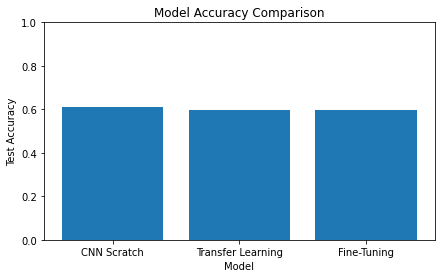

In [70]:
plt.figure(figsize=(7,4))

plt.bar(
    results_df['Model'],
    results_df['Test Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

plt.show()

In [71]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = transfer_model.predict(
        images,
        verbose=0
    )

    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

In [72]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.63      0.87      0.73       372
           1       0.79      0.37      0.50       115
           2       0.62      0.45      0.52       120
           3       0.41      0.45      0.43       126
           4       0.20      0.01      0.03        67

    accuracy                           0.60       800
   macro avg       0.53      0.43      0.44       800
weighted avg       0.58      0.60      0.56       800



In [73]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[324   3  19  25   1]
 [ 43  42   2  27   1]
 [ 52   2  54  12   0]
 [ 57   5   5  57   2]
 [ 39   1   7  19   1]]


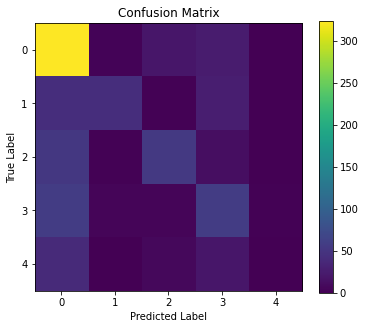

In [74]:
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.colorbar()

plt.show()

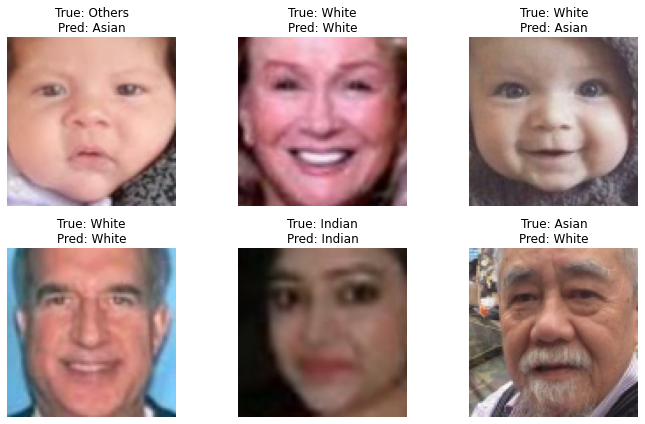

In [75]:
class_names = [
    'White',
    'Black',
    'Asian',
    'Indian',
    'Others'
]

images, labels_batch = next(iter(test_ds))

predictions = transfer_model.predict(
    images,
    verbose=0
)

predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"True: {class_names[labels_batch[i]]}\n"
        f"Pred: {class_names[predicted_labels[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

In [76]:
print("===== FINAL RESULTS =====")
print()
print("CNN Scratch:")
print("Accuracy =", accuracy_scratch)
print()
print("Transfer Learning:")
print("Accuracy =", accuracy_transfer)
print()
print("Fine-Tuning:")
print("Accuracy =", accuracy_finetune)

===== FINAL RESULTS =====

CNN Scratch:
Accuracy = 0.6100000143051147

Transfer Learning:
Accuracy = 0.5975000262260437

Fine-Tuning:
Accuracy = 0.5975000262260437
